In [1]:
%matplotlib inline

import importlib.util
import json
import sys
import pickle
from pathlib import Path

import corner
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from astropy import units as u
from astropy.coordinates import SkyCoord, Galactocentric, ICRS
from numpy.random import PCG64, SeedSequence
from ml_collections import ConfigDict

sys.path.append('/home/tvnguyen/projects/sbi_stream/ella_code/sbi_stream')

import sbi_stream
from sbi_stream.transforms import build_transformation
from sbi_stream.models import NPE, GNNEmbedding, TransformerEmbedding

torch.set_num_threads(8)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


### Read in the config file and the PS mock data

In [2]:
def json_to_config_dict(json_path: str) -> ConfigDict:
    with open(json_path, "r") as f:
        config_data = json.load(f)
    return ConfigDict(config_data)

config = json_to_config_dict('/global/homes/e/emarin4/scratch/sbi_stream_personal/ella_config_200k_nouncert.json')
model_config = config.model.value
pre_transforms_config = config.pre_transforms.value
norm_dict = config.norm_dict.value

features = config.data.value.features
labels = config.data.value.labels
print('features:', features)
print('labels:', labels)
#print('phi1-min:', config.data.value.phi1_min)
#print('phi1-max:', config.features.phi1_max)
phi1_min, phi1_max = -20, 16

features: ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
labels: ['log_mass', 'log_scale_radius']


In [3]:
# Commented this out, this is for old mocks that were not simulated using the exact same code as training data
# 
# _R = np.array([
#     [0.83697865, 0.29481904, -0.4610298 ],
#     [0.51616778, -0.70514011, 0.4861566 ],
#     [0.18176238, 0.64487142, 0.74236331],
# ])

# def galcen_to_stream_coords(part_xv, R=_R):
#     c_galcen = SkyCoord(
#         x=part_xv[:, 0] * u.kpc,
#         y=part_xv[:, 1] * u.kpc,
#         z=part_xv[:, 2] * u.kpc,
#         v_x=part_xv[:, 3] * u.km/u.s,
#         v_y=part_xv[:, 4] * u.km/u.s,
#         v_z=part_xv[:, 5] * u.km/u.s,
#         frame=Galactocentric()
#     )
#     c_icrs = c_galcen.transform_to(ICRS())

#     ra_rad  = c_icrs.ra.rad
#     dec_rad = c_icrs.dec.rad

#     icrs_vec = np.vstack([
#         np.cos(ra_rad) * np.cos(dec_rad),
#         np.sin(ra_rad) * np.cos(dec_rad),
#         np.sin(dec_rad),
#     ]).T
#     stream_vec = np.einsum("ij,kj->ki", R, icrs_vec)

#     phi1 = np.degrees(np.arctan2(stream_vec[:, 1], stream_vec[:, 0]))
#     phi2 = np.degrees(np.arcsin(stream_vec[:, 2]))

#     dist = c_icrs.distance.kpc
#     vr = c_icrs.radial_velocity.to(u.km/u.s).value
#     pm_ra_cosdec = c_icrs.pm_ra_cosdec.to(u.mas/u.yr).value
#     pm_dec = c_icrs.pm_dec.to(u.mas/u.yr).value

#     e_ra = np.vstack([-np.sin(ra_rad), np.cos(ra_rad), np.zeros(len(ra_rad))]).T
#     e_dec = np.vstack([
#         -np.sin(dec_rad) * np.cos(ra_rad),
#         -np.sin(dec_rad) * np.sin(ra_rad),
#          np.cos(dec_rad),
#     ]).T
#     pm_icrs_vec = pm_ra_cosdec[:, None] * e_ra + pm_dec[:, None] * e_dec
#     pm_stream_vec = np.einsum("ij,kj->ki", R, pm_icrs_vec)

#     phi1_rad = np.radians(phi1)
#     phi2_rad = np.radians(phi2)
#     e_phi1 = np.vstack([-np.sin(phi1_rad), np.cos(phi1_rad), np.zeros(len(phi1))]).T
#     e_phi2 = np.vstack([
#         -np.sin(phi2_rad) * np.cos(phi1_rad),
#         -np.sin(phi2_rad) * np.sin(phi1_rad),
#          np.cos(phi2_rad),
#     ]).T

#     pmphi1 = np.sum(pm_stream_vec * e_phi1, axis=1)
#     pmphi2 = np.sum(pm_stream_vec * e_phi2, axis=1)

#     return {'phi1': phi1, 'phi2': phi2, 'dist': dist,
#             'vr': vr, 'pm1': pmphi1, 'pm2': pmphi2}


# input_path = '/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/ps_mocks_852026/stream_ps_mock_m5e7_r0_3.pkl'

# with open(input_path, 'rb') as f:
#     data = pickle.load(f)
# posvel_all = np.asarray(data['part_xv'])
# stream = galcen_to_stream_coords(posvel_all)
# stream = np.column_stack([stream[k] for k in features])
# m = data['meta']

# # Apply the phi1 cut the training set was built with.
# phi1_idx = features.index('phi1')
# stream = stream[(stream[:, phi1_idx] >= phi1_min) & (stream[:, phi1_idx] <= phi1_max)]

In [4]:
mock_path = '/global/homes/e/emarin4/scratch/sbi_stream_personal/preprocessed_813_mocks/data.0.pkl'

with open(mock_path, 'rb') as f:
    data = pickle.load(f)

print(data)

truths = torch.stack([d.y.squeeze(0) for d in data]).numpy()

print(truths)

[Data(x=[165, 6], y=[1, 11], pos=[165, 2]), Data(x=[158, 6], y=[1, 11], pos=[158, 2]), Data(x=[161, 6], y=[1, 11], pos=[161, 2]), Data(x=[160, 6], y=[1, 11], pos=[160, 2]), Data(x=[160, 6], y=[1, 11], pos=[160, 2]), Data(x=[190, 6], y=[1, 11], pos=[190, 2]), Data(x=[198, 6], y=[1, 11], pos=[198, 2]), Data(x=[158, 6], y=[1, 11], pos=[158, 2]), Data(x=[164, 6], y=[1, 11], pos=[164, 2]), Data(x=[195, 6], y=[1, 11], pos=[195, 2]), Data(x=[165, 6], y=[1, 11], pos=[165, 2]), Data(x=[161, 6], y=[1, 11], pos=[161, 2]), Data(x=[188, 6], y=[1, 11], pos=[188, 2]), Data(x=[159, 6], y=[1, 11], pos=[159, 2]), Data(x=[169, 6], y=[1, 11], pos=[169, 2]), Data(x=[167, 6], y=[1, 11], pos=[167, 2]), Data(x=[198, 6], y=[1, 11], pos=[198, 2]), Data(x=[159, 6], y=[1, 11], pos=[159, 2]), Data(x=[189, 6], y=[1, 11], pos=[189, 2]), Data(x=[161, 6], y=[1, 11], pos=[161, 2]), Data(x=[161, 6], y=[1, 11], pos=[161, 2]), Data(x=[160, 6], y=[1, 11], pos=[160, 2]), Data(x=[162, 6], y=[1, 11], pos=[162, 2]), Data(x=[16

In [5]:
# AAU parameters
# TRUE_PARAMS_DICT = dict(
#     log_mass=np.log10(m['perturber_mass_Msun']),
#     log_scale_radius=np.log10(m['perturber_scaleradius_kpc']),
#     v_rel_perp=m['v_rel_perp_kms'],
#     v_rel_para=m['v_rel_para_kms'],
#     angle_pos_impact=m['angle_pos_at_impact_deg'],
#     angle_vel_delta=m['angle_vel_at_impact_deg'] + m['angle_pos_at_impact_deg'],
#     impact_param=m['impact_parameter_kpc'] / m['perturber_scaleradius_kpc'],
#     time_impact=-m['time_impact_Gyr'],
#     phi1_impact_today=m['phi1_impact_deg']
# )
# TRUE_PARAMS = np.array([TRUE_PARAMS_DICT[l] for l in labels])

# print('True parameters:')
# for l, v in TRUE_PARAMS_DICT.items():
#     print(f"{l}: {v}")

# # plot the streams
# fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)

# phi1 = stream[:, 0]
# for i, ax in enumerate(axes):
#     coord = stream[:, 1 + i]
#     ax.scatter(phi1, coord, s=0.5, c='k', alpha=0.5)
#     ax.set_ylabel(features[i + 1])
# ax.set_xlabel(features[0])

log_mass: 6.5947
log_scale_radius: -0.9886
phi1_impact_today: -10.0000
time_impact: -0.2500
log_impact_parameter: -0.3010
v_rel_para: 50.0000
v_rel_perp: 50.0000
angle_pos_at_impact: 25.0000
delta_angle: 45.0000
angle_vel_at_impact: 70.0000
delta_phi1: 5.0000


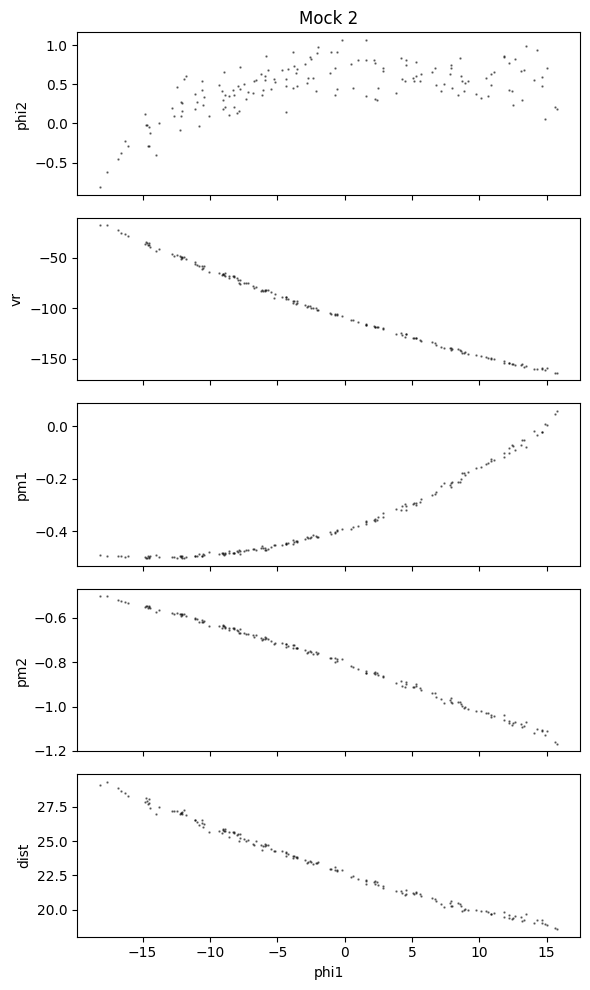

In [19]:
#Looking at 1 mock for testing

labels = ['log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact',
          'log_impact_parameter', 'v_rel_para', 'v_rel_perp',
          'angle_pos_at_impact', 'delta_angle', 'angle_vel_at_impact', 'delta_phi1']

i = 2
d = data[i]

truths = d.y.squeeze(0).numpy()
true_params_dict = dict(zip(labels, truths))

#Look at truths
for l, v in true_params_dict.items():
    print(f"{l}: {v:.4f}")

#Plot the stream
stream = d.x.numpy()   
phi1 = stream[:, 0]

features = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)
for j, ax in enumerate(axes):
    coord = stream[:, 1 + j]
    ax.scatter(phi1, coord, s=0.5, c='k', alpha=0.5)
    ax.set_ylabel(features[j+1])  
axes[-1].set_xlabel(features[0])
axes[0].set_title(f'Mock {i}')
plt.tight_layout()
plt.show()


### Read in the model

In [20]:
def build_embedding(model_config: ConfigDict):
    """Build a fresh (randomly initialized) embedding network.

    Args:
        model_config: Architecture config with a `model.embedding` section
            (see configs/debug.py / scripts/train_npe.py's config.model).

    Returns:
        A freshly constructed GNNEmbedding or TransformerEmbedding.

    Raises:
        ValueError: If `model_config.embedding.type` is not recognized.
    """
    embed_cfg = model_config.embedding
    model_type = embed_cfg.get('type', 'gnn')
    if model_type == 'gnn':
        return GNNEmbedding(
            input_size=model_config.input_size,
            gnn_args=embed_cfg.gnn,
            mlp_args=embed_cfg.mlp,
            loss_type=embed_cfg.get('loss_type', 'mse'),
            loss_args=embed_cfg.get('loss_args', None),
            conditional_mlp_args=embed_cfg.get('conditional_mlp', None),
            # NPE handles optimizer, scheduler, and pre_transforms
            optimizer_args=None,
            scheduler_args=None,
            pre_transforms=None,
        )
    elif model_type == 'transformer':
        return TransformerEmbedding(
            input_size=model_config.input_size,
            transformer_args=embed_cfg.transformer,
            loss_type=embed_cfg.get('loss_type', 'mse'),
            loss_args=embed_cfg.get('loss_args', None),
            mlp_args=embed_cfg.get('mlp', None),
            optimizer_args=None,
            scheduler_args=None,
            pre_transforms=None,
        )
    raise ValueError(f"Unsupported embedding model type: {model_type}")


def build_npe(
    model_config: ConfigDict,
    pre_transforms,
    norm_dict: dict,
    optimizer_args: ConfigDict = None,
    scheduler_args: ConfigDict = None,
):
    """Build a fresh NPE model, ready to have a checkpoint's weights loaded in.

    Args:
        model_config: Architecture config (round_0/model_config.json).
        pre_transforms: Pre-transformation pipeline passed to NPE.
        norm_dict: Fixed normalization dict for the whole run.
        optimizer_args: Optimizer config for this round's training.
        scheduler_args: Scheduler config for this round's training.

    Returns:
        A freshly constructed (randomly initialized) NPE model with the
        stored architecture. Call `load_state_dict` (or use
        `jgnn.training.fit(..., reset_optimizer=True)`) to warm-start it
        from a previous round's checkpoint.
    """
    embedding_nn = build_embedding(model_config)
    return NPE(
        input_size=model_config.input_size,
        output_size=model_config.output_size,
        flows_args=model_config.flows,
        embedding_nn=embedding_nn,
        optimizer_args=optimizer_args,
        scheduler_args=scheduler_args,
        norm_dict=norm_dict,
        pre_transforms=pre_transforms,
        init_flows_from_embedding=False,
    )

In [21]:
pre_transforms = build_transformation(**pre_transforms_config)
model = build_npe(model_config,pre_transforms=pre_transforms,norm_dict=norm_dict)
model = model.to(DEVICE).eval()

DEBUG embedding_output_size: 12
[NPE] Flows built from scratch with 146,196 parameters


In [22]:
import wandb
run = wandb.init(entity="desc_sbi_stream", project="sbi_aau_stepbystep")
artifact = run.use_artifact("desc_sbi_stream/sbi_aau_stepbystep/model-gec7xg0x:v41", type="model")
# artifact = run.use_artifact("desc_sbi_stream/sbi_aau_stepbystep/model-iocfmvpx:v41", type="model")
artifact_dir = artifact.download()

# load weights from the artifact
checkpoint_path = Path(artifact_dir) / "model.ckpt"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['state_dict'])

wandb:   1 of 1 files downloaded.  


<All keys matched successfully>

### Inference

In [23]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from sbi_stream.datasets import io_utils, preprocess_utils

In [24]:
# # create 10 different realizations of the stream, each with 200 points
# num_subsamples = 10
# num_per_subsample = 200
# uncertainty_model = None
# include_uncertainty = False

# x_loc, x_scale = torch.tensor(norm_dict.x_loc, dtype=torch.float32), torch.tensor(norm_dict.x_scale, dtype=torch.float32)

# # for consistency, you can try mimicking the preprocessing steps even if some steps are a bit redundant
# graphs = []
# for i in range(num_subsamples):
#     phi1, phi2 = stream[:, 0], stream[:, 1]
#     feat = stream.copy()

#     phi1_ppr, phi2_ppr, feat_ppr = preprocess_utils.subsample_arrays(
#         [phi1, phi2, feat], num_per_subsample=num_per_subsample)
#     phi1_ppr, phi2_ppr, feat_ppr, _, feat_unc_ppr = preprocess_utils.add_uncertainty(
#         phi1_ppr, phi2_ppr, feat_ppr, features, uncertainty_model=uncertainty_model)

#     # Create PyTorch Geometric Data object
#     pos = np.stack([phi1_ppr, phi2_ppr], axis=1)
#     if uncertainty_model is not None and include_uncertainty:
#         feat_ppr = np.concatenate([feat_ppr, feat_unc_ppr], axis=1)

#     graph = Data(
#         x=torch.tensor(feat_ppr, dtype=torch.float32),
#         pos=torch.tensor(pos, dtype=torch.float32),
#     )
#     graph.x = (graph.x - x_loc) / x_scale
#     graph = pre_transforms(graph)

#     graphs.append(graph)

# # this step is super redundant, but we can keep it for consistency with the training pipeline
# graph_loader = DataLoader(graphs, batch_size=1, shuffle=False)

In [25]:
#Since my mocks are already preprocessed, I can just use the data object directly

graph = data[i]  
graph = pre_transforms(graph)  
graph_loader = DataLoader([graph], batch_size=1, shuffle=False)

In [26]:
# Inference
all_posteriors = model.sample_from_loader(graph_loader, num_samples=100000)

# convert posterior back to physical units
y_loc = torch.tensor(norm_dict.y_loc, dtype=torch.float32)
y_scale = torch.tensor(norm_dict.y_scale, dtype=torch.float32)
all_posteriors = all_posteriors * y_scale + y_loc

all_posteriors = all_posteriors.cpu().numpy()  # move to CPU and convert to numpy array

100%|██████████| 1/1 [00:00<00:00, 11.59it/s]


In [27]:
# posterior = all_posteriors[0]
# fig = corner.corner(
#     posterior,
#     truths=true_params_dict.values(),
#     labels=labels,
#     show_titles=True,
#     title_fmt=".2f",
# )

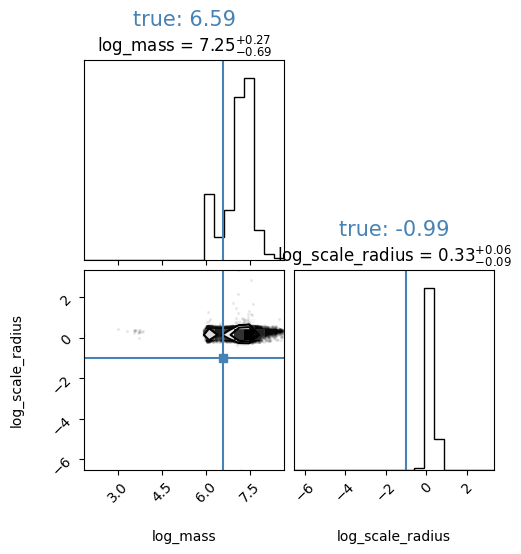

In [28]:
plt.close('all')  # clear any stale figure state

# indices for the params you care about
idx = [labels.index('log_mass'), labels.index('log_scale_radius')]

posterior_sub = all_posteriors[0][:, idx]          # (num_samples, 2)
truths_sub = [true_params_dict['log_mass'], true_params_dict['log_scale_radius']]
labels_sub = ['log_mass', 'log_scale_radius']

fig = corner.corner(
    posterior_sub,
    truths=truths_sub,
    labels=labels_sub,
    show_titles=True,
    title_fmt=".2f",
)

# diagonal axes for a 2-param corner plot are at positions 0 and 3
n_params = len(labels_sub)
diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]

truth_color = "#4682b4"
for ax, true_val, label in zip(diag_axes, truths_sub, labels_sub):
    ax.text(
        0.5, 1.15,                      # x, y in axes-fraction coords (above existing title)
        f"true: {true_val:.2f}",
        color=truth_color,
        ha='center', va='bottom',
        transform=ax.transAxes,
        fontsize=15,
    )